# Plot: drug response breadth vs. magnitude

Loads the treatment-breadth summary from `explore_leads.ipynb` (`results/leads/{organoid,single_cell}_treatment_breadth.parquet`) and plots, per drug, how many patients respond (breadth) against how many features respond (magnitude).

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from notebook_init_utils import init_notebook

warnings.filterwarnings("ignore")
root_dir, in_notebook = init_notebook()

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)

figures_path = pathlib.Path(root_dir, "4.linear_modeling/figures/leads")
figures_path.mkdir(parents=True, exist_ok=True)
results_path = pathlib.Path(root_dir, "4.linear_modeling/results/leads")

breadth = {
    name: pd.read_parquet(results_path / f"{name}_treatment_breadth.parquet")
    for name in ["organoid", "single_cell"]
}

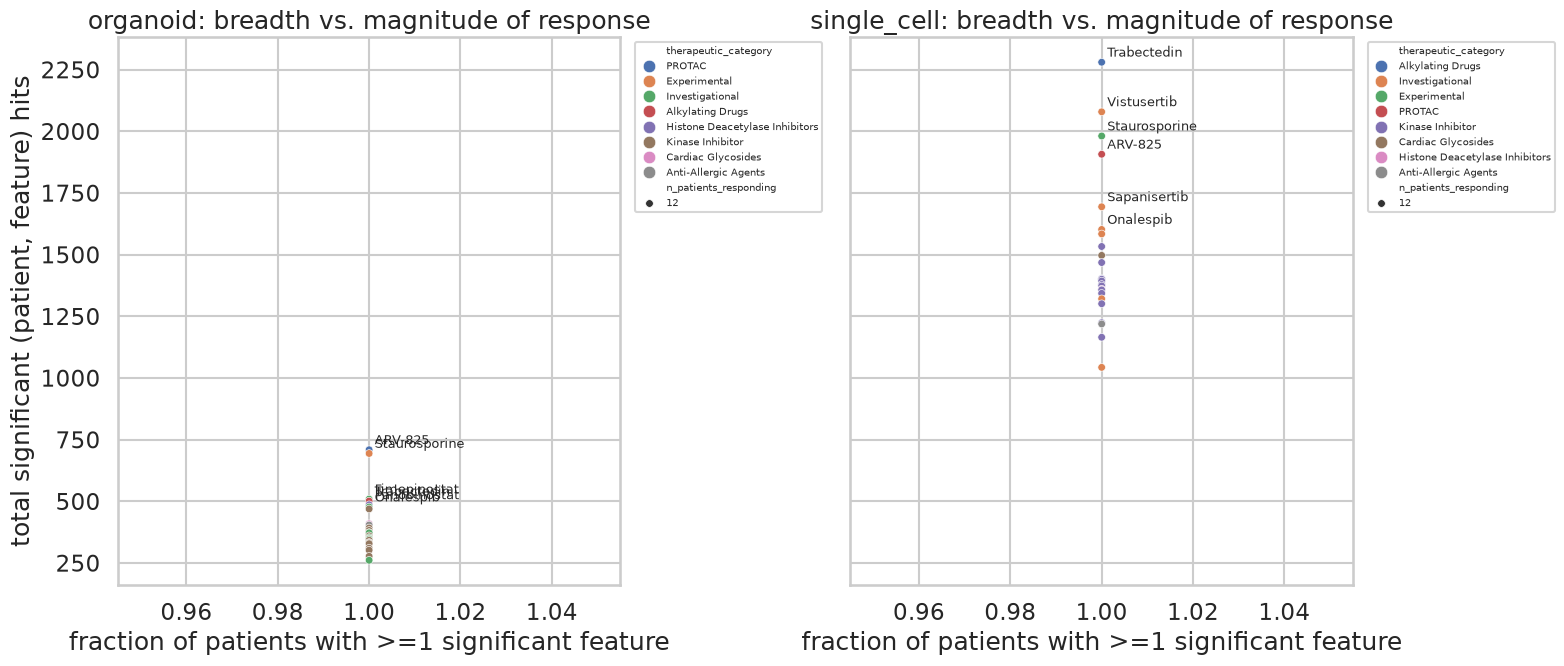

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
for ax, (name, summary) in zip(axes, breadth.items()):
    sns.scatterplot(
        data=summary,
        x="frac_patients_responding",
        y="total_sig_features",
        hue="therapeutic_category",
        size="n_patients_responding",
        sizes=(30, 250),
        ax=ax,
    )
    for _, row in (
        summary.sort_values("total_sig_features", ascending=False).head(6).iterrows()
    ):
        ax.annotate(
            row["drug"],
            (row["frac_patients_responding"], row["total_sig_features"]),
            fontsize=9,
            xytext=(4, 4),
            textcoords="offset points",
        )
    ax.set_title(f"{name}: breadth vs. magnitude of response")
    ax.set_xlabel("fraction of patients with >=1 significant feature")
    ax.set_ylabel("total significant (patient, feature) hits")
    ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(figures_path / "breadth_vs_magnitude.png", dpi=600, bbox_inches="tight")
plt.show()

**Reading the plot:** top-right = broad, strong responders (most promising generalizable hits). Bottom-right = a drug hitting many features but only in one or two patients — worth checking *which* patients, since that heterogeneity could itself be the interesting biology.